## Section 1: Import Required Libraries and Configuration

In [1]:
import os
import sys
import yaml
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F

from tqdm import tqdm
import librosa
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0,str(PROJECT_ROOT))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14


Using device: cpu


## Section 2: Load and Prepare Datasets

In [2]:
import os 
from utils import AudioPreprocessor
import utils
config_path = "../configs/config.yaml"

if os.path.exists(config_path):
    preprocessor = AudioPreprocessor(config_path = config_path)
    print("Init Preprocessor Successfully!")
else:
    config_path_abs = "configs/config.yaml"
    if os.path.exists(config_path_abs):
        preprocessor = AudioPreprocessor(config_path = config_path_abs)
        print("Init Preprocessor Successfully!")
    else:
        print("File not found! Check file 'config.yaml' in'configs'?")   
    

Init Preprocessor Successfully!


In [3]:
def show_config():
    print("CONFIGURATION")
    print("Sample Rate: ",preprocessor.target_sr)
    print("Duration: ", preprocessor.duration)
    print("n_fft: ",preprocessor.n_fft)
    print("n_mels: ",preprocessor.n_mels)
    print("Hop_length: ",preprocessor.hop_length)
    print("Class Mapping:", preprocessor.class_mapping)
show_config()

CONFIGURATION
Sample Rate:  22050
Duration:  4.0
n_fft:  2048
n_mels:  128
Hop_length:  512
Class Mapping: {'gunshot': 0, 'explosion': 1, 'siren': 2, 'glass_breaking': 3, 'scream': 4, 'dog_bark': 5, 'fire_crackling': 6}


In [4]:
import librosa
import librosa.display
import IPython.display as ipd
from pathlib import Path

from utils.preprocess import AudioPreprocessor
from utils.dataset import AudioEventDataset
from utils.augmentation import AudioAugmentor

CONFIG_PATH = "../configs/config.yaml"
METADATA_PATH = "../data/processed/spectrograms/processed_metadata.csv"

print("Library Ready!")

Library Ready!


In [5]:
import pandas as pd
import os
from pathlib import Path

BASE_DIR = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

US8K_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'UrbanSound8K','metadata', 'UrbanSound8K.csv')
ESC50_PATH = os.path.join(BASE_DIR, 'data','raw', 'ESC-50/','ESC-50-master','meta','esc50.csv')

def merge_and_explore():
    df_us8k = pd.read_csv(US8K_PATH)
    df_esc50 = pd.read_csv(ESC50_PATH)
    us8k_subset = pd.DataFrame({
        'file_name': df_us8k['slice_file_name'],
        'class_name': df_us8k['class'],
        'source_dataset': 'UrbanSound8K',
        'fold': df_us8k['fold']
    })
    esc50_subset = pd.DataFrame({
        'file_name': df_esc50['filename'],
        'class_name': df_esc50['category'],
        'source_dataset': 'ESC50',
        'fold': df_esc50['fold']
    })
    
    df_merged = pd.concat([us8k_subset, esc50_subset], ignore_index=True)
    
    print("="*40)
    print("STATISTIC AFTER MERGED")
    print("="*40)
    print(f"Total Sample: {len(df_merged)}")
    print(f"Total Class (Unique Classes): {df_merged['class_name'].nunique()}")
    print("\nNumber samples for each Dataset:")
    print(df_merged['source_dataset'].value_counts())
    
    return df_merged

df_all = merge_and_explore()


STATISTIC AFTER MERGED
Total Sample: 10732
Total Class (Unique Classes): 58

Number samples for each Dataset:
source_dataset
UrbanSound8K    8732
ESC50           2000
Name: count, dtype: int64


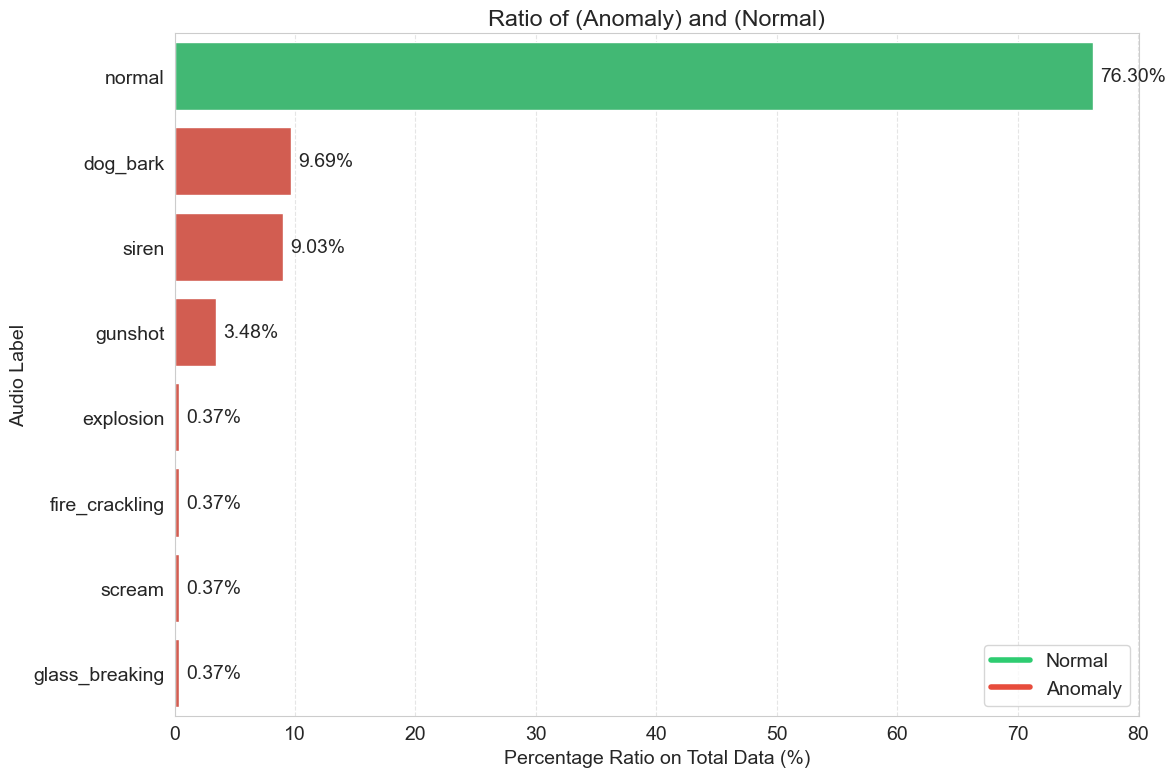

In [6]:
def process_and_plot_anomaly_distribution(df_merged):
    mapping = {
        'dog_bark': 'dog_bark', 'dog': 'dog_bark',
        'siren': 'siren',
        'gun_shot': 'gunshot', 'gunshot': 'gunshot',
        'explosion': 'explosion', 'fireworks': 'explosion',
        'fire_crackling': 'fire_crackling', 'crackling_fire': 'fire_crackling',
        'scream': 'scream', 'crying_baby': 'scream',
        'glass_breaking': 'glass_breaking'
    }
    
    target_classes = ['dog_bark', 'siren', 'gunshot', 'explosion', 'fire_crackling', 'scream', 'glass_breaking']

    df_merged['final_class'] = df_merged['class_name'].map(mapping)
    
    df_merged['final_class'] = df_merged.apply(
        lambda row: row['final_class'] if row['final_class'] in target_classes else 'normal', 
        axis=1
    )

    counts = df_merged['final_class'].value_counts()
    percentage = (counts / len(df_merged) * 100).round(2)
    
    dist_df = pd.DataFrame({
        'Class': counts.index, 
        'Number': counts.values, 
        'Percentage (%)': percentage.values
    })

    plt.figure(figsize=(12, 8))
    colors = ['#2ecc71' if x == 'normal' else '#e74c3c' for x in dist_df['Class']]
    
    ax = sns.barplot(x='Percentage (%)', y='Class', data=dist_df, palette=colors)
    
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f%%', padding=5)
        
    plt.title("Ratio of (Anomaly) and (Normal)")
    plt.xlabel("Percentage Ratio on Total Data (%)")
    plt.ylabel("Audio Label")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='#2ecc71', lw=4),
                    Line2D([0], [0], color='#e74c3c', lw=4)]
    ax.legend(custom_lines, ['Normal', 'Anomaly'], loc='lower right')
    
    plt.tight_layout()
    plt.show()

    return df_merged
df_final = process_and_plot_anomaly_distribution(df_all)

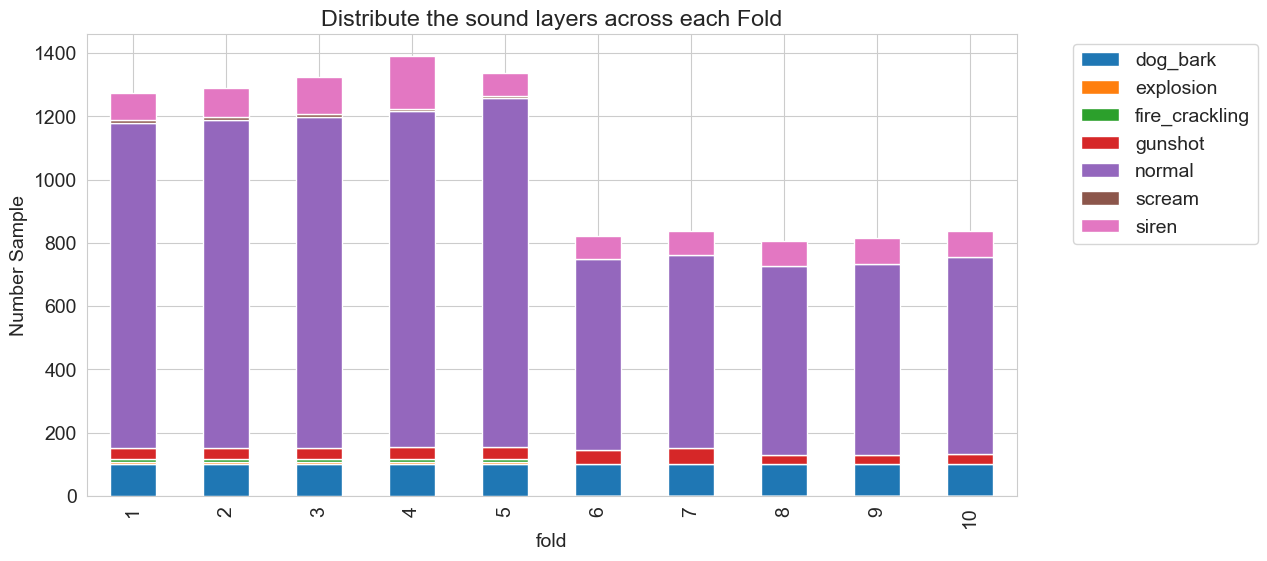

In [7]:
PROCESSED_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'spectrograms', 'processed_metadata.csv')
df = pd.read_csv(PROCESSED_PATH)
fold_counts = pd.crosstab(df['fold'], df['target_class'])
fold_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Distribute the sound layers across each Fold")
plt.ylabel("Number Sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

..\data/raw/UrbanSound8K\audio\fold6\208030-3-2-0.wav
..\data/raw/UrbanSound8K\audio\fold8\52633-3-0-8.wav
..\data/raw/UrbanSound8K\audio\fold9\52740-3-0-1.wav
..\data/raw/UrbanSound8K\audio\fold2\4201-3-0-0.wav
..\data/raw/UrbanSound8K\audio\fold8\190996-3-0-8.wav


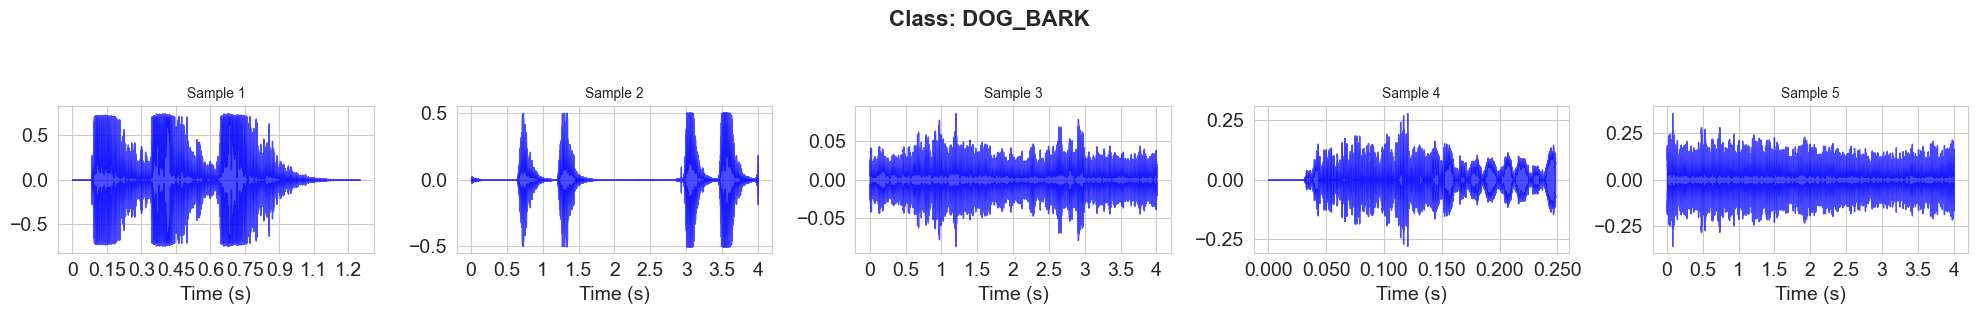

..\data/raw/ESC-50/ESC-50-master\audio\4-119647-D-48.wav
..\data/raw/ESC-50/ESC-50-master\audio\2-117615-B-48.wav
..\data/raw/ESC-50/ESC-50-master\audio\1-25777-A-48.wav
..\data/raw/ESC-50/ESC-50-master\audio\3-172881-A-48.wav
..\data/raw/ESC-50/ESC-50-master\audio\4-119648-C-48.wav


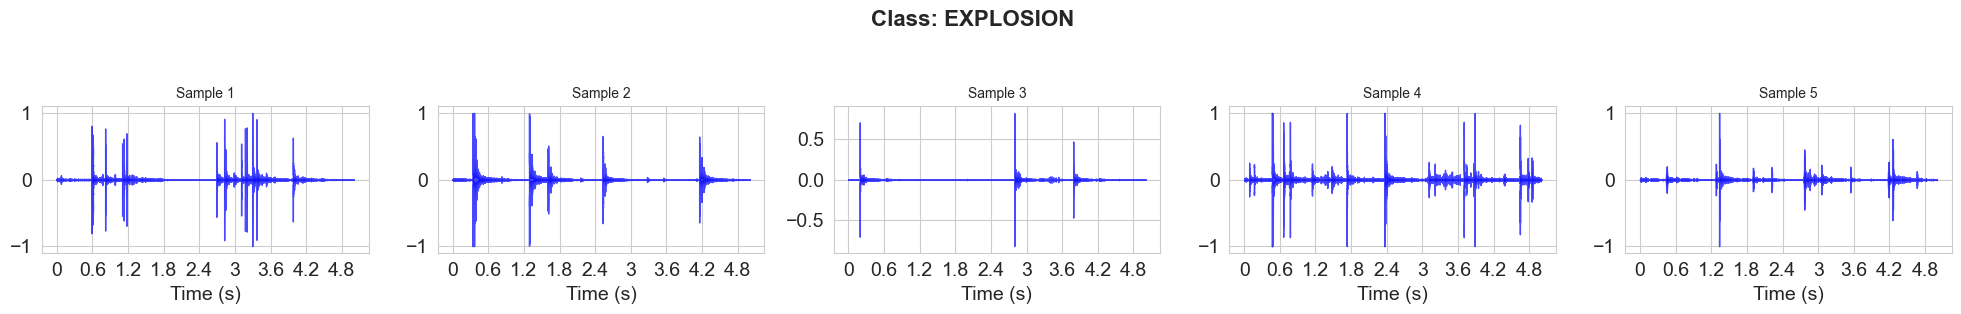

..\data/raw/ESC-50/ESC-50-master\audio\2-18766-A-12.wav
..\data/raw/ESC-50/ESC-50-master\audio\2-28314-B-12.wav
..\data/raw/ESC-50/ESC-50-master\audio\2-18766-B-12.wav
..\data/raw/ESC-50/ESC-50-master\audio\3-157187-A-12.wav
..\data/raw/ESC-50/ESC-50-master\audio\1-17808-B-12.wav


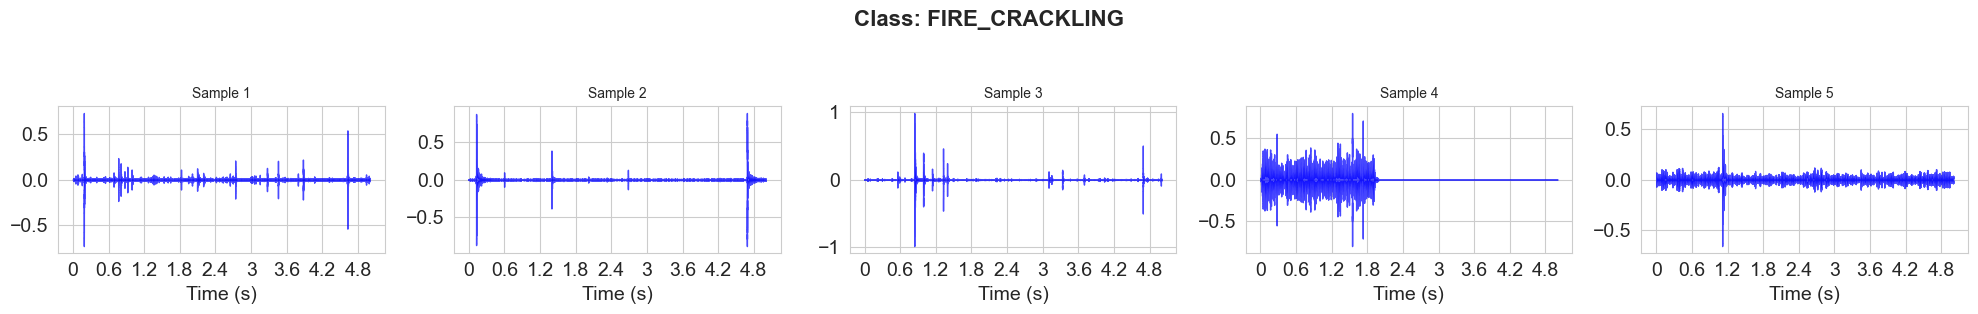

..\data/raw/UrbanSound8K\audio\fold2\197320-6-12-0.wav
..\data/raw/UrbanSound8K\audio\fold5\162432-6-5-0.wav
..\data/raw/UrbanSound8K\audio\fold1\174290-6-1-0.wav
..\data/raw/UrbanSound8K\audio\fold6\135544-6-9-0.wav
..\data/raw/UrbanSound8K\audio\fold4\23161-6-0-0.wav


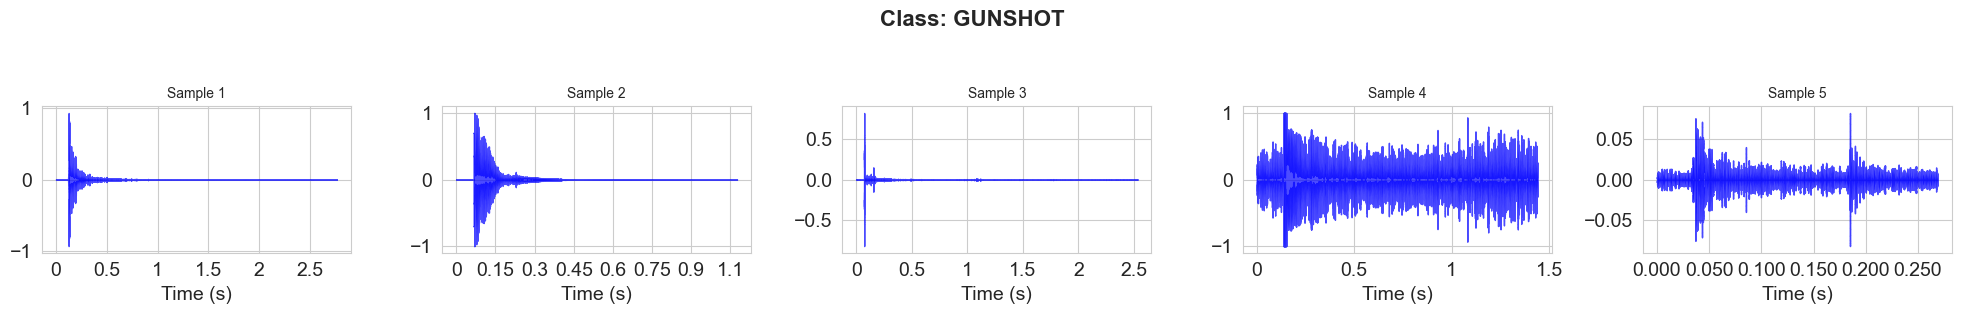

..\data/raw/ESC-50/ESC-50-master\audio\1-60997-B-20.wav
..\data/raw/ESC-50/ESC-50-master\audio\1-22694-A-20.wav
..\data/raw/ESC-50/ESC-50-master\audio\5-198411-G-20.wav
..\data/raw/ESC-50/ESC-50-master\audio\5-198411-C-20.wav
..\data/raw/ESC-50/ESC-50-master\audio\4-167077-C-20.wav


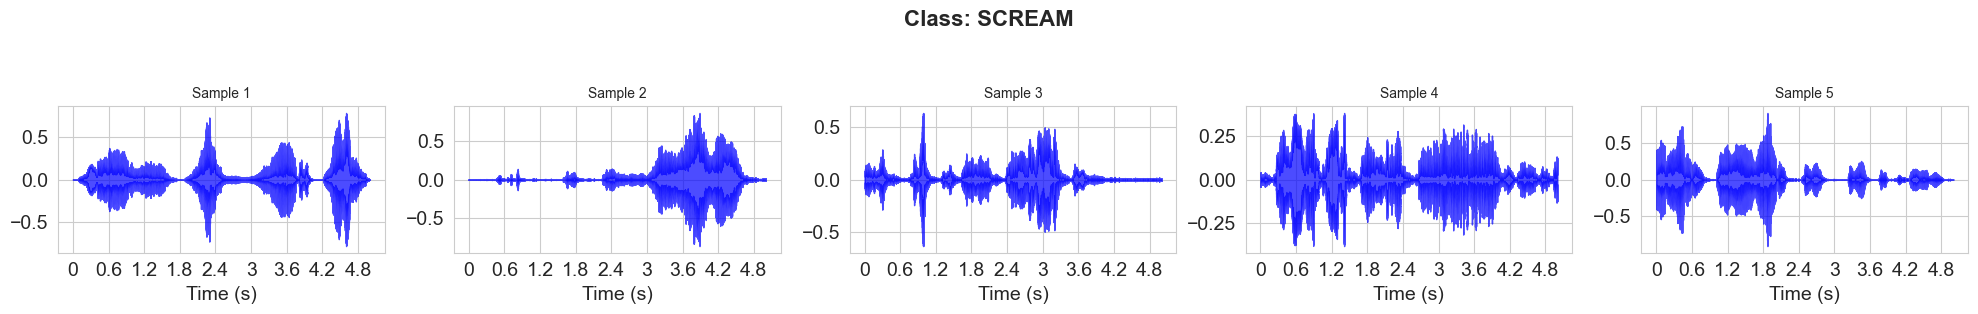

..\data/raw/UrbanSound8K\audio\fold9\66601-8-0-1.wav
..\data/raw/UrbanSound8K\audio\fold4\159751-8-0-12.wav
..\data/raw/UrbanSound8K\audio\fold8\117181-8-0-1.wav
..\data/raw/UrbanSound8K\audio\fold1\40722-8-0-7.wav
..\data/raw/UrbanSound8K\audio\fold7\107357-8-1-0.wav


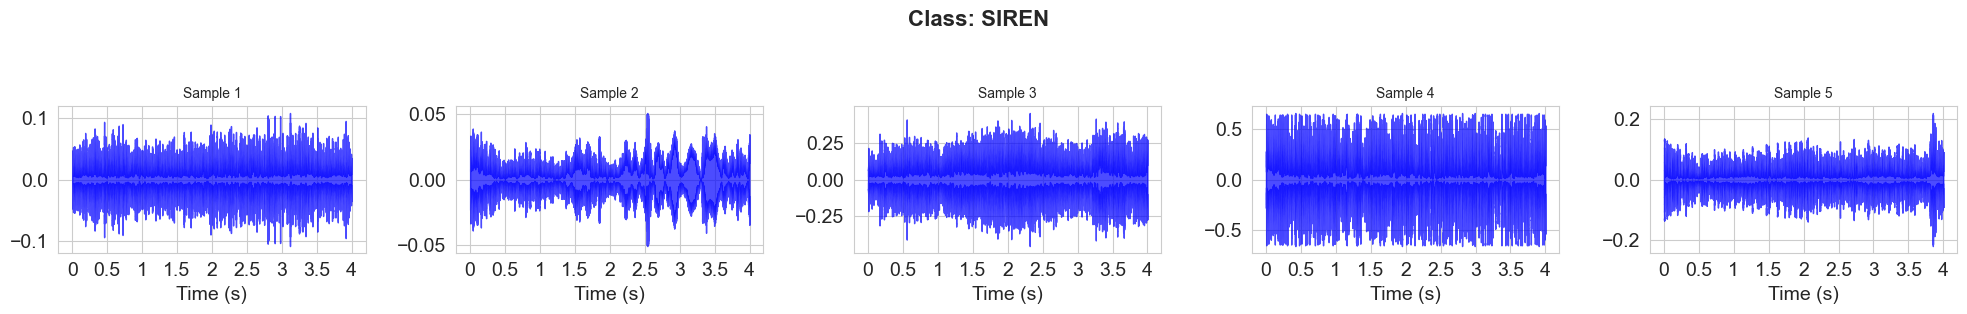

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import pandas as pd

DATA_PATH = "../data"
MERGED_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'merged_dataset.csv')
df_merge = pd.read_csv(MERGED_PATH)

df_samples = df_merge[df_merge['target_class'] != 'normal'] \
             .groupby('target_class') \
             .sample(n=5, random_state=42)

def visualize_all_classes(df):
    classes = df['target_class'].unique()
    
    for cls in classes:
        class_df = df[df['target_class'] == cls]
        
        # Tạo khung hình: 1 hàng, 5 cột cho mỗi class
        fig, axes = plt.subplots(1, 5, figsize=(20, 3))
        fig.suptitle(f'Class: {cls.upper()}', fontsize=16, fontweight='bold', y=1.05)
        
        for i, (idx, row) in enumerate(class_df.iterrows()):
            file_path = os.path.join('..', row['file_path'])
            print(file_path)
            ax = axes[i]
            
            try:
     
                y, sr = librosa.load(file_path, sr=None)

                librosa.display.waveshow(y, sr=sr, ax=ax, color='blue', alpha=0.7)
                
                ax.set_title(f"Sample {i+1}", fontsize=10)
                if i > 0: ax.set_ylabel('') # Chỉ để nhãn trục Y ở hình đầu tiên cho gọn
                ax.set_xlabel('Time (s)')
                
            except Exception as e:
                ax.set_title("Error loading file")
                ax.axis('off')
        
        plt.tight_layout()
        plt.show()

# Gọi hàm để bắt đầu vẽ
visualize_all_classes(df_samples)

--- VISUALIZING 7 AUDIO CLASSES ---


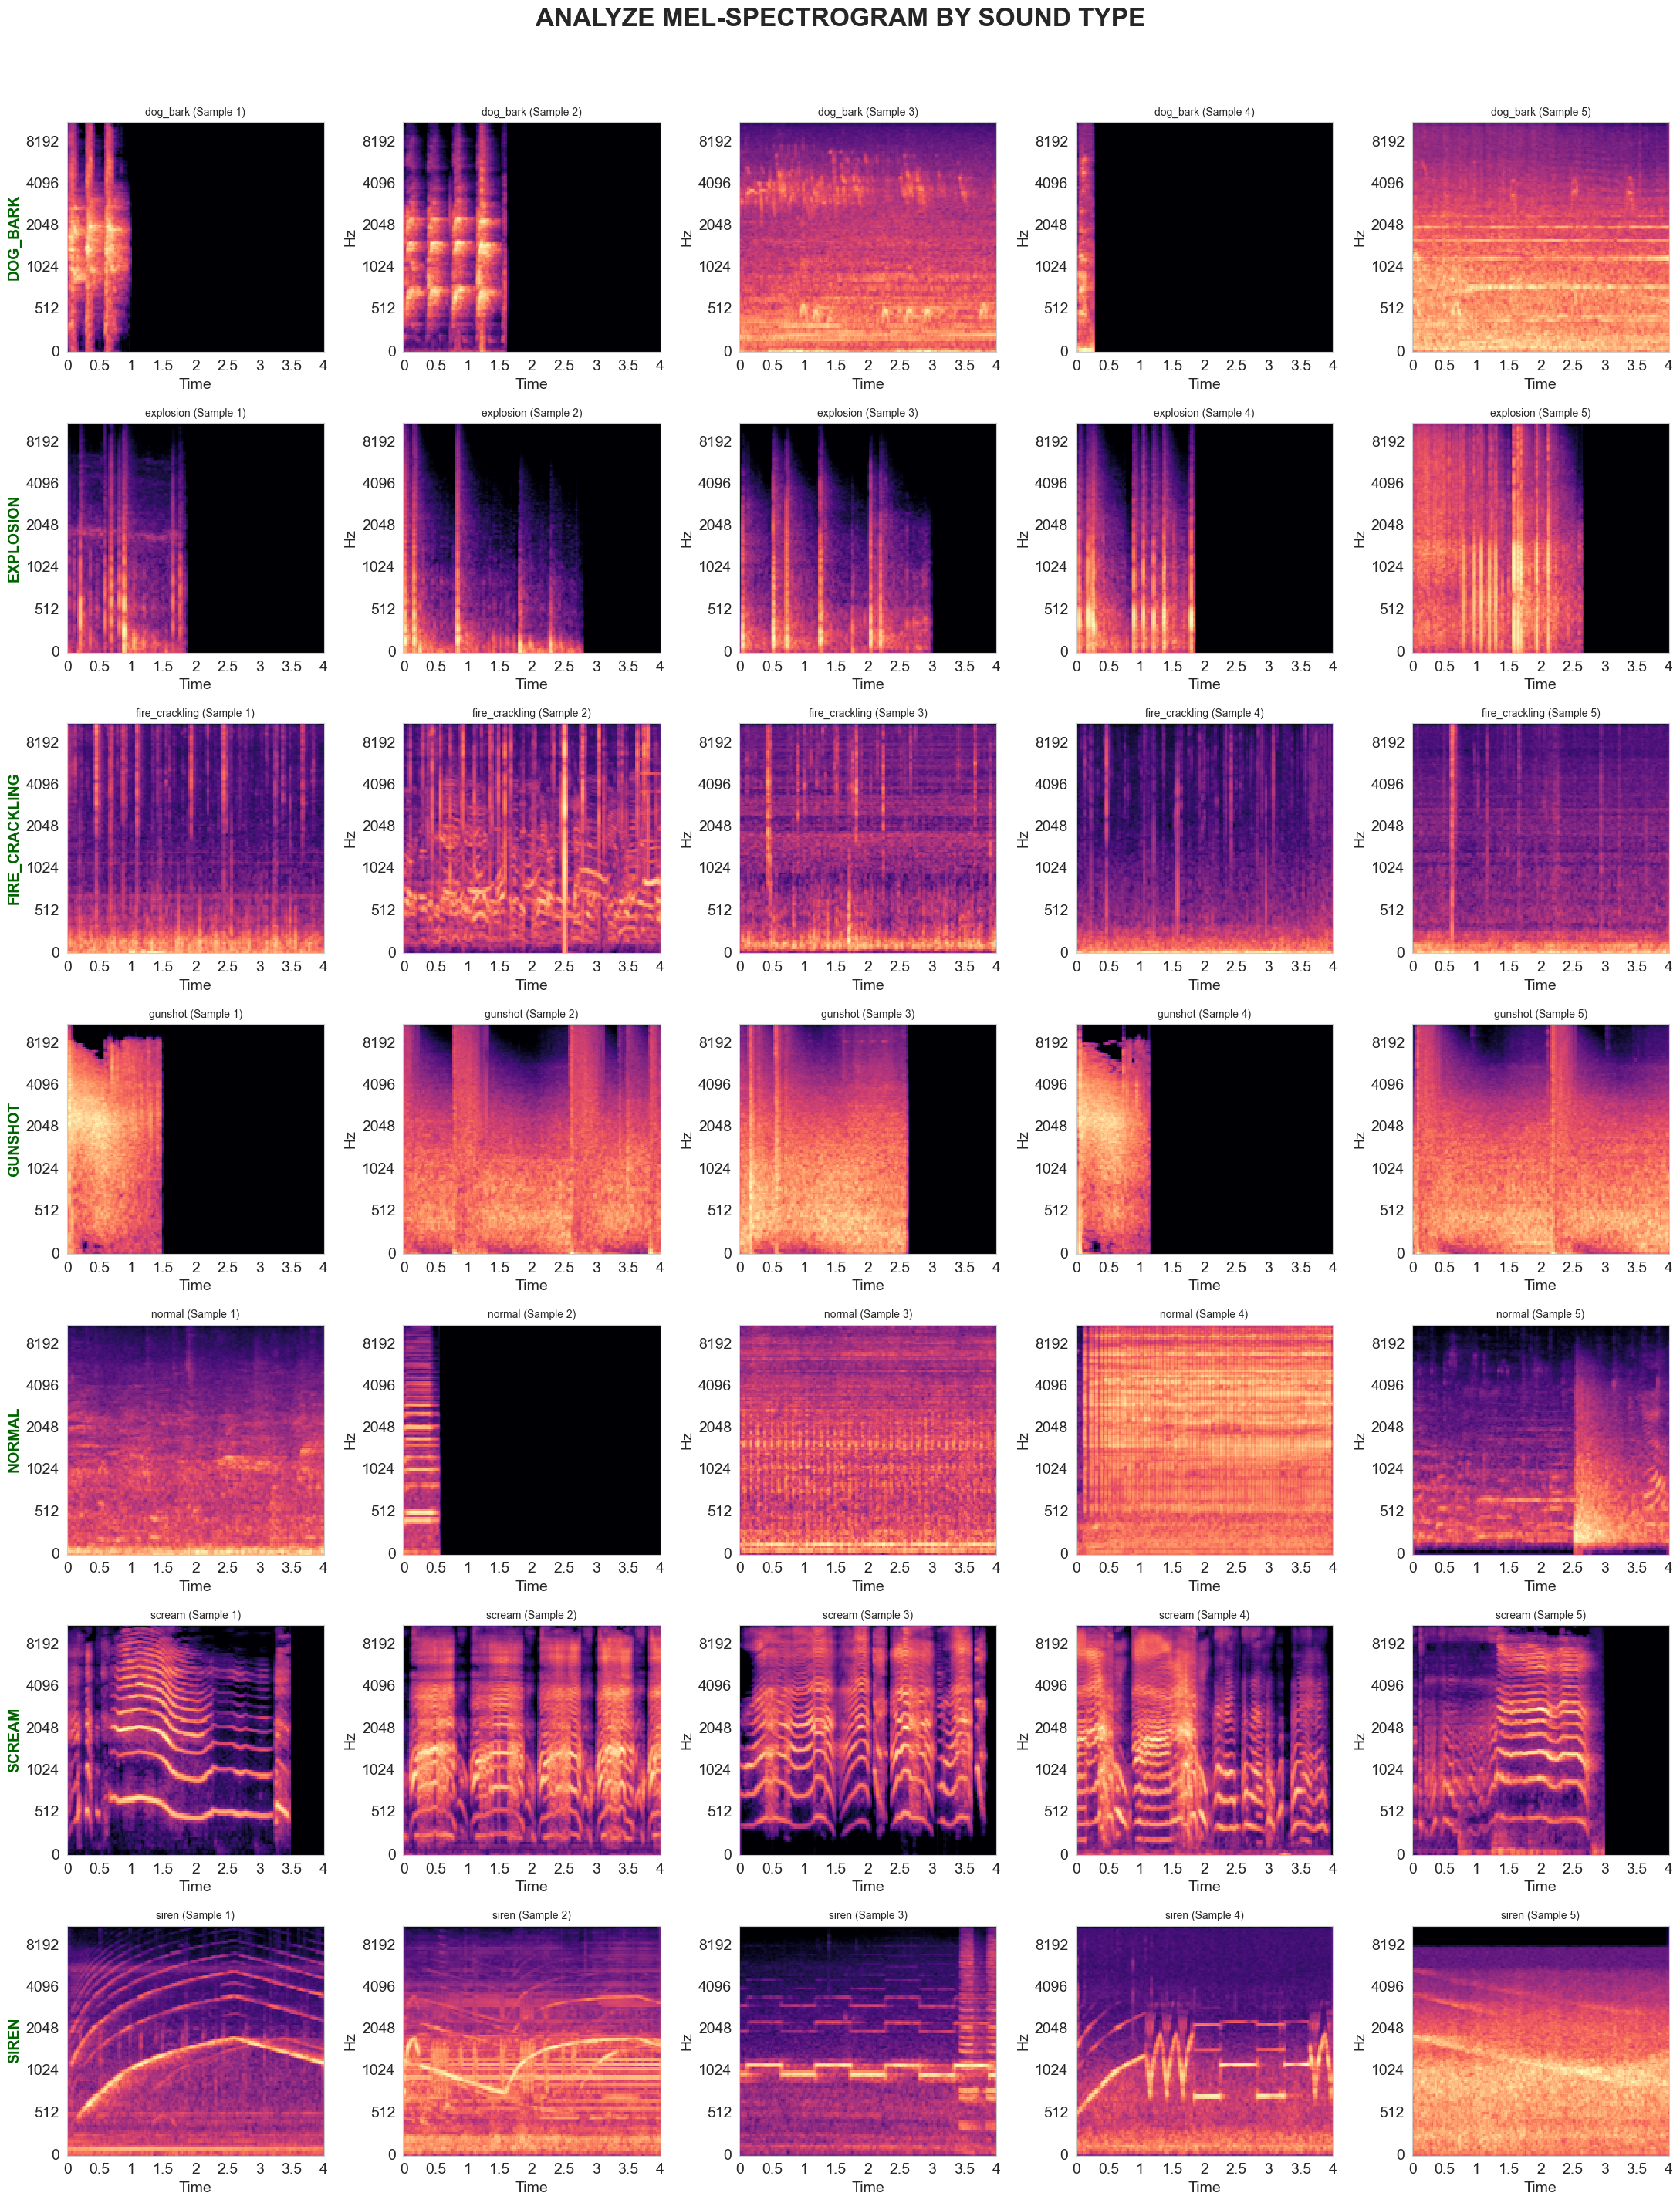

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
from sklearn.preprocessing import LabelEncoder

# --- 1. KHỞI TẠO LẠI NHÃN (Sửa lỗi 'le' is not defined) ---
# Giả sử df của bạn có cột 'target_class' chứa nhãn (số hoặc chữ)
le = LabelEncoder()

# Nếu target_class đang là số (0, 1, 2...), ta cần map nó với tên gốc 
# (Bạn có thể bỏ qua bước fit này nếu đã có danh sách tên class)
if df['target_class'].dtype == 'int64' or df['target_class'].dtype == 'int32':
    # Nếu là số, ta tạo tên tạm thời để code không lỗi
    unique_ids = sorted(df['target_class'].unique())
    le.fit([f"Class_{i}" for i in unique_ids]) 
else:
    # Nếu là chữ, ta fit bình thường
    df['target_class'] = le.fit_transform(df['target_class'])

# --- 2. CẤU HÌNH ---
N_SAMPLES_PER_CLASS = 5
class_ids = sorted(df['target_class'].unique())  
n_classes = len(class_ids)

# 3. KHỞI TẠO FIGURE
fig, axes = plt.subplots(n_classes, N_SAMPLES_PER_CLASS, figsize=(22, 4 * n_classes))

# Đảm bảo axes là mảng 2 chiều
if n_classes == 1:
    axes = np.expand_dims(axes, axis=0)

print(f"--- VISUALIZING {n_classes} AUDIO CLASSES ---")

for i, cls_id in enumerate(class_ids):
    # Lấy tên hiển thị (Inverse transform từ ID)
    try:
        cls_display_name = le.inverse_transform([cls_id])[0]
    except:
        cls_display_name = f"ID_{cls_id}"

    # Lấy mẫu ngẫu nhiên
    class_df = df[df['target_class'] == cls_id]
    num_to_sample = min(N_SAMPLES_PER_CLASS, len(class_df))
    samples = class_df.sample(num_to_sample, random_state=42)
    
    for j in range(N_SAMPLES_PER_CLASS):
        ax = axes[i, j]
        if j < len(samples):
            path = samples.iloc[j]['feature_path']
            
            # Sửa đường dẫn tương đối nếu cần
            if not os.path.exists(path):
                path = os.path.join("..", path)
            
            if os.path.exists(path):
                try:
                    # Load spectrogram (.npy)
                    spec = np.load(path, allow_pickle=True)
                    
                    # Vẽ Mel-Spectrogram
                    img = librosa.display.specshow(spec, ax=ax, x_axis='time', y_axis='mel')
                    
                    # Hiển thị tên Class ở cột đầu tiên
                    if j == 0:
                        ax.set_ylabel(f"{cls_display_name.upper()}", 
                                      fontsize=14, fontweight='bold', color='darkgreen')
                    
                    ax.set_title(f"{cls_display_name} (Sample {j+1})", fontsize=10)
                        
                except Exception as e:
                    ax.text(0.5, 0.5, "Error Load Data", color='red', ha='center')
                    print(f"Error loading {path}: {e}")
            else:
                ax.text(0.5, 0.5, "File Not Found", color='orange', ha='center')
        else:
            # Ẩn các ô thừa nếu class không đủ 5 mẫu
            ax.axis('off')

plt.suptitle("ANALYZE MEL-SPECTROGRAM BY SOUND TYPE", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()